# Le modèle de ségrégation de Schelling
*ARE DYNAMIC - 2025*

## Préambule

En Décembre 2016 disparaissait Thomas C. Schelling. Economiste, récipiendaire du Prix de la Banque de Suède en sciences économiques (communément appelé et considéré comme le prix Nobel d’économie), il a travaillé sur de nombreux sujets, en particulier l’analyse des conflits.

Une de ses contributions a permis de mieux comprendre les phénomènes de ségrégation. Plus précisément, le propos de Schelling fut d’étudier la dynamique par laquelle **des phénomènes de ségrégation extrêmes** peuvent survenir, en dépit de **préférences qui peuvent sembler faiblement discriminantes individuellement**. Ainsi, même si chaque individu se déclare prêt à accepter une certaine proportion d’invidus « différents » dans son voisinage, le résultat final peut être que la population se regroupe en régions très homogènes.

Cette étude peut être menée à l’aide de modèles connus sous le nom d’automates cellulaires. Un des automates les plus célèbres est le [jeu de la vie](https://fr.wikipedia.org/wiki/Jeu_de_la_vie), proposé par John Conway en 1970. Il existe de nombreux autres automates cellulaires dont le comportement est relativement bien étudié, et la littérature est riche à ce sujet. Nous recommandons la lecture de l’article [2] de Jean-Paul Delahaye.

## Objectifs

Dans ce notebook nous allons essayer de modéliser la répartition d'une population humaine sur une aire urbaine (un *monde*). Nous allons essayer de comprendre les différentes formes de ségration et de communautarisme pouvant avoir lieu dans les villes.
Nous partons d'une hypothèse primordiale : **chaque individu est indépendant cependant il ne peut pas se sentir confortable dans un quartier où les habitants sont en majorité "différents" de lui.**

Dans un premier temps nous allons modéliser cette répartition une aire urbaine simple : une rue ou une avenue (modèle linéaire).
Puis dans un second temps nous modéliserons cette répartition à l'échelle d'une ville (modèle spatial).


# 1ère partie : Modèle linéaire

Considérons un monde *linéaire* (c’est en fait le premier modèle étudié par Schelling dans son article [1], à quelques détails près). Le modèle se compose des éléments suivants.

- Les *individus* sont de deux *types* (« 0 » et « 1 »), disposés spatialement sur une ligne de taille $n$ (le *monde*).
- Le *voisinage* d'un *individu* est constitué de ses 8 voisins de part et d'autre de sa cellule (4 à sa gauche et 4 à sa droite). Il faut noter que le nombre de voisins peut varier selon la localisation (pour les individus en bout de ligne).
- Le *seuil de satisfaction* : un *individu* est satisfait si une majorité (faible) de ses voisins est du même *type* que lui (i.e. il veut **au moins** autant de voisins du même *type* que lui que de voisins d'un *type* différent).
- Le *mode de déplacement* : un *individu* non satisfait va chercher à se déplacer pour trouver un emplacement qui le satisfasse (un emplacement dont le *voisinage* respecte son *seuil de satisfaction*). Dans le cas où plusieurs emplacements peuvent le satisfaire, un *individu* se déplace vers l’emplacement le plus proche. Si deux emplacements à la même distance sont satisfaisants, l'emplacement de droite est privilégié.
- La *dynamique des déplacements* : tous les individus sont considérés, de gauche à droite. Chaque individu non satisfait **s'insère** à l’emplacement satisfaisant le plus proche. Un *tour* est terminé lorsque tous les individus ont été considérés.


À l'issu d'un *tour* des individus peuvent se retrouver à nouveau insatisfaits, dû aux déplacements de leurs voisins.
Partant d’un état initial, le processus est répété jusqu’à équilibre, c’est-à-dire jusqu’à ce que plus aucun individu insatisfait ne puisse se déplacer, ou qu’une situation de blocage soit détectée. Cela peut nécessiter plusieurs *tours*.

### Example

Pour illustrer le propos, considérons la situation initiale suivante :

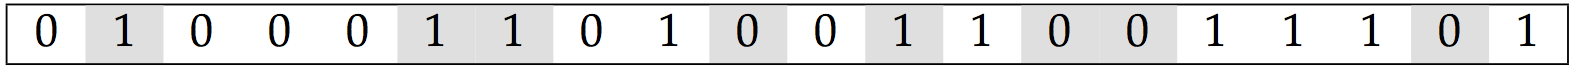


Les individus non satisfaits sont indiqués en gris dans la table. Le premier individu à se déplacer sera donc le deuxième en partant de la gauche. En effet, son voisinage ne comprend qu’un autre individu de type "1" (et 4 de type "0"). Pour trouver une place satisfaisante, il va devoir se déplacer de 6 cases vers la droite (l'emplacement satisfaisant le plus proche).

Le nouvel état du monde sera alors (l’individu s’étant déplacé est en gras):

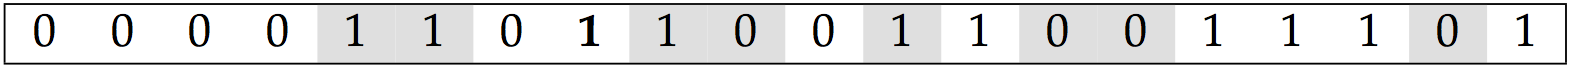



### Références
- [1] Thomas C. Schelling, [Dynamic Models of Segregation](http://www.stat.berkeley.edu/~aldous/157/Papers/Schelling_Seg_Models.pdf), Journal of Mathematical Sociology (1971) 143-186
- [2] J.-P. Delahaye, [Le royaume du jeu de la vie](http://www.lifl.fr/~jdelahay/dnalor/Jeudelavie.pdf), Pour la Science (2009) 378

#  Etude du modèle "linéaire"

**Objectifs : implémenter le modèle de Schelling en python, le tester sur un exemple simple puis étudier l'impact que peuvent avoir les paramètres du modèle sur le monde.**

Nous allons étudier l’impact des paramètres du modèle : 
- la taille du voisinage,
- le seuil de satisfaction des individus,
- la configuration initiale,
- les règles de mouvement (le mode de déplacement).

Pour quantifier l'impact de ces paramètres, en plus de l'observation visuelle de l'évolution de notre monde, nous utiliserons les métriques suivantes : 
- le nombre d’individus satisfaits à l’équilibre,
- la taille (moyenne) des regroupements homogènes observés et leur nombre,
- la moyenne sur tous les individus du nombre de voisins du même type qu’eux,
- le nombre de tours nécessaires pour arriver à un état stable.

In [279]:
import numpy as np
import random

from matplotlib import pyplot as plt


In [280]:
# Paramètres du modèle Schelling (à modifier, ne pas oublier de réexécuter la cellule)
neigh = 4          # Taille du voisinage (d'un côté, pour avoir le total faire *2)
threshold = 0.5     # Seuil de satisfaction
max_iter = 5        # Nombre de tours
size = 22           # Taille du monde (n)

Notre monde est représenté par une liste de 0 et de 1. Par exemple :

In [282]:
cells = [0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1]

In [283]:
assert len(cells) == size



Nous pouvons considérer que ce monde représente une rue, la population de chaque maison étant de type "0" ou "1". 





La fonction ```print_world``` convertit un monde en une chaîne de caractères pour l'afficher à l'écran.

In [286]:
def print_world(cells):
    ''' le cells est une chaîne de caractères de type "0" ou "1" '''
    result = "|"
    for i in cells:
        result += str(i)+"|"
    return result

In [287]:
print_world(cells)

'|0|1|0|0|0|1|1|0|1|0|0|1|1|1|0|0|1|1|1|1|0|1|'

**Question 1** : Implémenter la fonction ```neighborhood``` qui prend comme paramètres un monde ```cells```, la position ```c``` d'un individu dans le monde et la taille du voisinage ```neigh``` et retourne une liste contenant le type des voisins d'un individu (**attention aux bords du monde**).

In [289]:
def neighborhood(cells,c,neigh):
    if c-neigh<0 and c+neigh>len(cells)-1:
        return cells[0:c] + cells[c+1:len(cells)]
    elif c-neigh<0:
        return cells[0:c] + cells[c+1:c+neigh+1]
    elif c+neigh>len(cells)-1:
        return cells[c-neigh:c] + cells[c+1:len(cells)]
    else:
        return cells[c-neigh:c] + cells[c+1:c+neigh+1]

print(neighborhood(cells, 1, 4))
    


[0, 0, 0, 0, 1]


**Question 2 :** Implémenter la fonction ```satisfaction_ratio```, prenant comme paramètres un monde ```cells```, la position ```c``` d'un individu dans le monde et la taille du voisinage ```neigh```, retourne le niveau de satisfaction d'un individu (le pourcentage de ses voisins qui sont du même type que lui).

In [291]:
def satisfaction_ratio(cells,c,neigh):
    ls=neighborhood(cells,c,neigh)
    type0=0
    type1=0
    for x in ls:
        if x==0:
            type0+=1
        if x==1:
            type1+=1
    if cells[c]==0:
        return type0/len(ls)
    if cells[c]==1:
        return type1/len(ls)
print(satisfaction_ratio(cells,1,4))



0.2


**Question 3** :  Implémenter la fonction ```is_happy```, prenant comme paramètres un monde ```cells```, la position ```c``` d'un individu dans le monde, la taille du voisinage ```neigh``` et ```threshold``` son seuil de satisfaction, retourne un booléen indiquant si l'individu à la position ```c``` est satisfait.

In [293]:
def is_happy(cells,c,neigh,threshold):
    st = satisfaction_ratio(cells,c,neigh)
    if st >= threshold:
        return True
    else:
        return False


**Question 4 :** En s'inspirant de la fonction ```print_world```, implémenter la fonction ```print_satisfaction``` une réprésentation graphique de la statisfaction des individus du monde ```cells```.

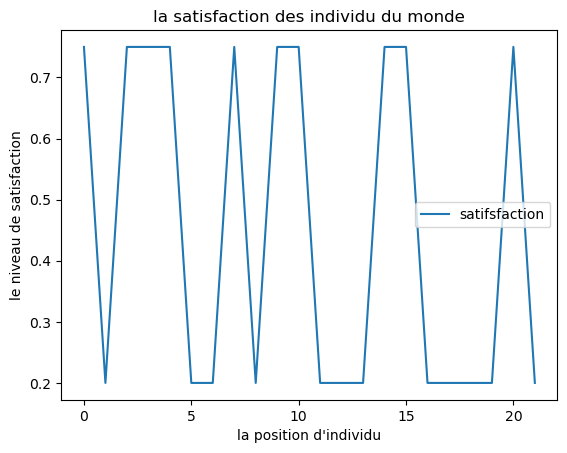

In [295]:
neigh = 4
def print_satisfaction(cells):
    return [satisfaction_ratio(cells,i,neigh) for i in cells]

x = np.array([j for j in range(size)])
y = print_satisfaction(cells)

plt.figure()
plt.plot(x,y,label='satifsfaction')
plt.title('la satisfaction des individu du monde')
plt.xlabel("la position d'individu")
plt.ylabel("le niveau de satisfaction")
plt.legend()
plt.draw()
    

**Question 5 :** Implémenter la fonction ```relocation``` **retirant** un individu à la position ```c``` et l'**insérant** juste avant la position```d``` (avec $0\leq d \leq n+1$). **Cette fonction doit retourner une copie du monde**.

In [297]:
def relocation(c,d,cells):
    if c<d:
        return cells[0:c]+cells[c+1:d]+[cells[c]]+cells[d:]
    elif c>d:
        return cells[0:d]+[cells[c]]+cells[d:c]+cells[c+1:]
    else:
        return cells

print(relocation(1,2,cells))

[0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1]


**Question 6 :** Implémenter la fonction ```nearest_satisfying``` qui, pour un individu insatisfait, retourne la position satisfaisante la plus proche (en cas d'égalité : préférer la position satisfaisante de droite).  
*Indice :* Pour savoir si une position est satisfaisante nous pouvons essayer d'insérer l'individu et lui demander s'il est satisfait de son nouveau voisinage.

**Question 6bis (optionnelle)** : S'interroger sur la rapidité de cette opération et proposer une solution plus efficace.

In [300]:
def nearest_satisfying(indiv,cells,neigh,threshold):
    distance = len(cells) - 1
    position = None
    for d in range(1,len(cells)):
        re = relocation(indiv,d,cells)
        if indiv < d -1 and is_happy(re,d-1,neigh,threshold) and np.abs(d-1-indiv) <= distance:
            distance = np.abs(d-1-indiv)
            position = d-1
        if indiv > d and is_happy(re,d,neigh,threshold) and np.abs(d-indiv) <= distance: 
            distance = np.abs(d-indiv)
            position = d     
    return position
             
insatis = [i for i in range(size) if not is_happy(cells,i,neigh,threshold)]
print(insatis)
individu = insatis[random.randint(0,len(insatis)-1)]
print(individu)
print(nearest_satisfying(individu,cells,neigh,threshold))
    

[1, 5, 6, 9, 10, 11, 14, 15, 20]
15
11


### Dynamique

La dynamique consiste à répéter les déplacements des individus. Schelling suggère de considérer les individus un par un, en partant de la gauche, et de les faire se déplacer s'ils le peuvent. Un *tour* est terminé lorsque tous les individus ont été considérés. On peut esuite répéter les tours. Mais quand s'arrêter avec cette dynamique ? 

Nous considérons différents critères de convergence :
* Lorsque tous les individus sont satisfaits. Cependant, rien ne garantit que le système puisse parvenir à un état où tous les individus sont satisfaits (cela peut arriver mais c'est plutôt exceptionnel). 
* Lorsque plus aucun individu ne peut se déplacer. Ce critère est plus pertinent, mais il cache une difficulté : le système ne parvient pas non plus nécessairement dans un état où plus aucun individu ne peut se déplacer. Ce critère seul peut donc mener à des boucles infinies.
* Nous emploierons donc un garde-fou, qui consistera à poser un nombre maximal de tours (ou itérations). Si le système n'est pas stabilisé, selon le critère précédent, après ce nombre d'itérations : la dynamique s'arrête. 

**Question 7**: Implémenter la fonction ```schelling``` qui effectue un *tour* du modèle de schelling. Vérifier l'exactitude de cette fonction sur des exemples de votre choix (papier et stylo utiles). 

In [304]:
def schelling(seuil_satisfaction, n_neigh,world):
    insatisf = [i for i in range(len(world)) if not is_happy(world,i,neigh,threshold)]
    for i in insatisf:
        p = nearest_satisfying(i,world,neigh,seuil_satisfaction)
        if p is not None:
            liste = relocation(i,p,world)
    
    return liste

print(schelling(0.6,2,cells))

[0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1]


**Question 8 :** Implémenter la fonction finale du modèle de schelling ```linear_schelling``` prenant en compte tous les paramètres du modèle (taille du voisinage ```neigh```, seuil de satisfaction ```threshold```, nombre d'itérations ```max_iter```).

In [306]:
def linear_schelling(neigh, threshold, max_iter, world):
    n = 0
    worlds = [world]
    monde = world[:]
    while n < max_iter:
        insatisf = [i for i in range(len(monde)) if not is_happy(monde,i,neigh,threshold)]
        if not insatisf:
            break
        for i in insatisf:
            p = nearest_satisfying(i,monde, neigh, threshold) 
            if p is not None:
                monde = relocation(i, p, monde)   
        worlds.append(monde)
        n += 1
    return worlds

print(linear_schelling(neigh,threshold,max_iter,cells))


[[0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1], [0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1], [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]


Normalement, à ce stade, nous avons réussi à implémenter le modèle de Schelling sur un monde linéaire. Nous allons, maintenant, essayer de déterminer l'impact des paramètres sur la dynamique de notre *monde*. Pour se faire nous allons avoir besoin de mondes plus grands et d'un nombre de types d'individu plus grand que 2.

**Question 9** : Proposer une méthode pour générer des mondes linéaires de manière automatique et aléatoire (refléchir aux paramètres de cette méthode). Implémenter cette méthode dans la fonction ```generate_linear_world```.  
*Indice*: on peut s'intéresser à la fonction ```random.choice``` du package ```numpy```. 

In [309]:
def generate_linear_world(n):
    return [random.choice([0, 1]) for _ in range(n)]

print(generate_linear_world(5))
print(generate_linear_world(15))



[1, 1, 1, 0, 0]
[1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0]


La fonction ```plot_world``` permet d'afficher notre monde de manière un peu plus élégante :

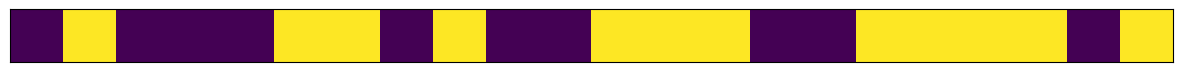

In [311]:
def plot_world(world):
    if type(world) == list:
        A = np.array([world])
    else:
        A = world
    plt.figure(figsize=(15,12)) # (30,30) = Taille de la figure
    plt.imshow(A,cmap='viridis')
    plt.tick_params(top=False, bottom=False, right=False, left=False, labelleft=False, labelbottom=False)
    plt.draw()
plot_world(cells)    

**Question 10** : Implémenter des fonctions retournant les métriques suivantes (une métrique = une fonction) :
- ```happiness_rate``` le ratio d’individus satisfaits,
- ```mean_size_communities``` la taille (moyenne) des regroupements homogènes observés,
- ```nb_communities``` le nombre de regroupements homogènes,
- ```mean_same_type``` la moyenne sur tous les individus du ratio de voisins du même type qu’eux,
- ```nb_iter_to_stability``` le nombre de tours nécessaires pour arriver à un état stable.

In [313]:
def happiness_rate(world, threshold, neigh):
    satisf = [i for i in range(len(world)) if is_happy(world, i, neigh, threshold)]
    return len(satisf) / len(world)


def mean_size_communities(world):
    size_list = []
    current_size = 1
    for i in range(1, len(world)):
        if world[i] == world[i-1]:
            current_size += 1
        else:
            size_list.append(current_size)
            current_size = 1
    size_list.append(current_size)
    return np.mean(size_list)

print(mean_size_communities(cells))

def nb_communities(world):
    number = 1
    for i in range(1, len(world)):
        if world[i] == world[i-1]:
            pass
        else:
            number += 1
    return number
print(nb_communities(cells))


def mean_same_type(world, neigh):
    ratio_list = []
    for i in range(0, len(world)):
        ratio_list.append(satisfaction_ratio(world, i, neigh))
    return np.mean(ratio_list)
print(mean_same_type(cells, 2))


def nb_iter_to_stability(neigh, threshold, max_iter,world):
    worlds = linear_schelling(neigh,threshold, max_iter,world)
    for i in range(1,len(worlds)):
        if len(worlds) > 1 and worlds[i] == worlds[i-1]:
            return i-1
    return max_iter

print(nb_iter_to_stability(4, 0.5, 5, cells))

1.8333333333333333
12
0.4318181818181818
5


**Question 11 :** Faire varier les paramètres du modèle et observer l'évolution des différentes métriques. Tracer les courbes correspondantes, si elles sont judicieuses, en utilisant matplotlib ; puis décrire les phénomènes observés (pas plus de 3 courbes, un paragraphe par phénomène observé).

*Indices :* Tracer l'évolution du taux de satisfaction au fil des tours. Faire évoluer le seuil de satisfaction par pas de 0.1 de 0 à 1. Etudier la taille des regroupements homogènes en fonction de ce seuil. Nombre de tours nécessaires pour arriver à un état stable en fonction de la taille du monde. 

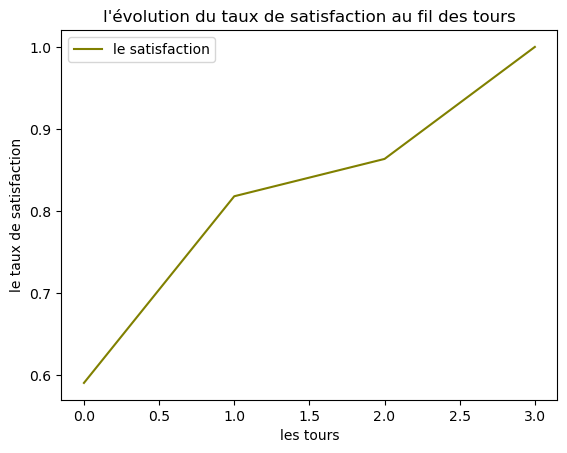

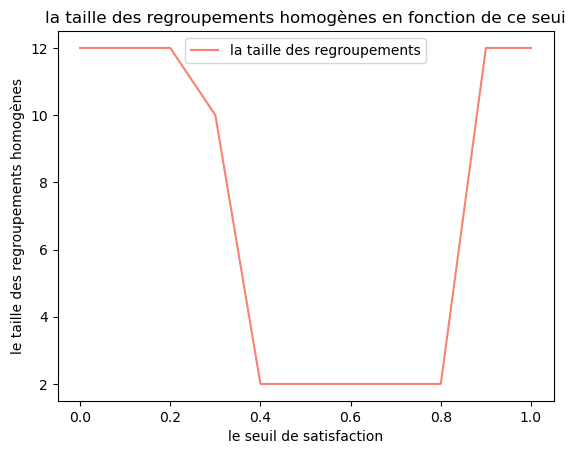

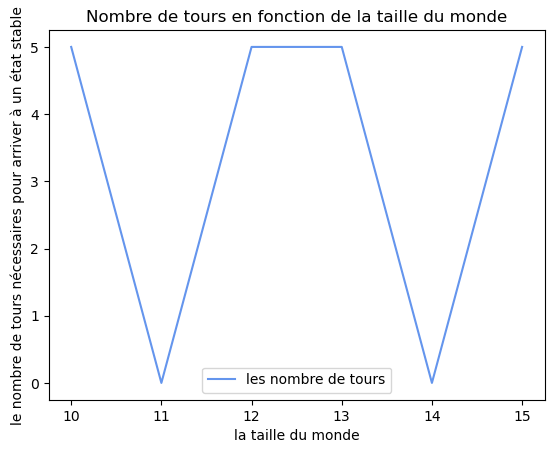

In [315]:
#graphe1
def graphe1(neigh, max_iter, threshold,world):
    worlds = linear_schelling(neigh,threshold, max_iter,world)
    satisfaction = [happiness_rate(i, threshold, neigh) for i in worlds]
    return satisfaction

satisfaction = graphe1(neigh, max_iter, threshold, cells)

plt.figure()
plt.plot(range(len(satisfaction)), satisfaction, label='le satisfaction',color='olive')
plt.title("l'évolution du taux de satisfaction au fil des tours")
plt.xlabel("les tours")
plt.ylabel("le taux de satisfaction")
plt.legend()
plt.draw()

#le graphe1 montre le taux de satisfaction augmentant au fil du temps.



#graphe2          
threshold_range = np.arange(0, 1.1, 0.1)
def graphe2(neigh, max_iter, threshold_range,world):
    nb_regroupements=[]
    for t in threshold_range:
        worlds = linear_schelling(neigh,t, max_iter,world)
        regroupements = nb_communities(worlds[-1])
        nb_regroupements.append(regroupements)
    return nb_regroupements  

nb_regroupements = graphe2(neigh, max_iter, threshold_range, cells)

plt.figure()
plt.plot(threshold_range,nb_regroupements,label='la taille des regroupements',color='salmon')
plt.title("la taille des regroupements homogènes en fonction de ce seui")
plt.xlabel("le seuil de satisfaction")
plt.ylabel("le taille des regroupements homogènes")
plt.legend()
plt.draw()

#Lorsque le seul de satisfaction augmente, la taille des regroupements homogènes reste élevée jusqu'à environ 0.3, 
#puis diminue brusquement pour atteindre un minimum vers 0.6 ~0.8, avant de remonter rapidement à sa valeur initiale proche de 1


#graphe3 
def graphe3(neigh, max_iter, threshold):
    worlds = [generate_linear_world(n) for n in range(10,16)]
    nb_stability = [nb_iter_to_stability(neigh, threshold, max_iter,i) for i in worlds]
    taille = [len(i) for i in worlds]
    return nb_stability,taille

nb_stability,taille = graphe3(neigh, 5, threshold)

plt.figure()
plt.plot(taille,nb_stability,label = 'les nombre de tours',color = 'cornflowerblue')
plt.title("Nombre de tours en fonction de la taille du monde")
plt.xlabel("la taille du monde")
plt.ylabel("le nombre de tours nécessaires pour arriver à un état stable")
plt.legend()
plt.draw()

#Le graphique3 montre comment nombre de tours évolue en fonction de la taille du monde.

# 2ème partie : Modèle spatial

Dans cette partie le monde que nous allons considérer n'est plus constitué d'une seule dimension mais de deux dimensions. Si l'on pouvait assimiler le modèle "linéaire" à l'application du modèle de Schelling dans une rue, l'extension à une deuxième dimension permet de modéliser le modèle de Schelling à l'échelle d'une ville (pensons à une carte divisée en emplacements carrés de même taille, chaque carré représentant un immeuble ou un pâté de maisons).

Un emplacement est déterminé par ses coordonnées $(X,Y)$. Par exemple, l'emplacement $(0,0)$ est situé en tout en haut à gauche et l'emplacement $(n,m)$ tout en bas à droite.

L’extension du modèle linéaire au modèle spatial n’est pas triviale. En effet, si toutes les localisations sont occupées, il n’est pas si évident de définir les règles de déplacements (où se déplacent les individus « chassés » de leur localisation ?).

Il est alors plus aisé d’introduire des localisations non occupées. Dans ce cas, les individus non satisfait se déplacent au hasard vers une localisation inoccupée. Contrairement au modèle linéaire, la nouvelle localisation ne satisfait pas forcément le seuil de préférence et n'est pas forcément la plus proche (ces alternatives pourront être implémentées en question 5).

## Etude du modèle spatial

In [318]:
# Paramètres du modèle Schelling (à modifier, ne pas oublier de réexécuter la cellule)
neigh = 1       # Taille du voisinage
threshold = 0.5 # Seuil de satisfaction
max_iter = 5    # Nombre de tours
n,m = 7,7       # Taille du monde (n,m)

**Question 1** : Implanter la fonction ```generate_spatial_world``` permettant de générer des mondes spatiaux aléatoirement (de même : s'interroger sur les paramètres nécessaires). Utiliser ```numpy.array```.  
*Indice* : Pour un emplacement innocupé, nous pouvons créer un nouveau type.

In [320]:
def generate_spatial_world(n, m):
    """precondition : on utilise chiffre 0 pour signaliser les localisations non occupées """
    return np.array([[np.random.randint(0,3) for _ in range(m)] for _ in range(n)])

spatial_world = generate_spatial_world(n,m)
print(spatial_world)

[[0 0 2 1 2 0 2]
 [1 2 2 2 2 2 0]
 [0 1 0 1 2 0 1]
 [2 1 2 0 0 2 0]
 [2 2 0 2 2 2 2]
 [0 0 1 0 0 0 2]
 [0 0 0 1 0 0 0]]


**Question 2 :** Implémenter la fonction ```spatial_schelling```, permettant d'appliquer le modèle de schelling sur un monde spatial.  
**Utiliser la [distance de Tchebychev](https://fr.wikipedia.org/wiki/Distance_de_Tchebychev)** dès qu'il est question de comparer des distances entre individus : pour les voisins nous pouvons considérer tous les emplacements dont la distance est inférieure ou égale à ```neigh```.

In [373]:
def distance_Tchebychev(x1,y1,x2,y2):
    return max(np.abs(x1-x2),np.abs(y1-y2))
    
def neighborhood2(world,x,y,neigh):
    voisins = []
    for l in range(len(world)):
        for c in range(len(world[0])):
            if distance_Tchebychev(x,y,l,c) <= neigh and (x!=l or y!=c):
                voisins.append(world[l][c])
    return voisins


def satisfaction_ratio2(world,x,y,neigh):
    ls=neighborhood2(world,x,y,neigh)
    type2=0
    type1=0
    if ls == []:
        return 0
    for i in ls:
        if i==1:
            type1+=1
        if i==2:
            type2+=1
    if world[x][y]==1:
        return type1/len(ls)
    elif world[x][y]==2:
        return type2/len(ls)
    else:
        return 0

def is_happy2(world,x,y,neigh,threshold):
    st = satisfaction_ratio2(world,x,y,neigh)
    if st >= threshold:
        return True
    else:
        return False



def relocation2(world,x,y):
    empty_places = [(l,c) for l in range(len(world)) for c in range(len(world[0])) if world[l][c] == 0]
    if empty_places == []: 
        return world 
    new_position = empty_places[np.random.randint(0, len(empty_places))]
    new_x, new_y = new_position
    monde = world[:]
    monde[new_x][new_y] = world[x][y]
    monde[x][y] = 0 
    return monde


import copy

def spatial_schelling(neigh, threshold, max_iter, world):
    n = 0
    worlds = [np.copy(world)] 
    monde = copy.deepcopy(world)
    while n < max_iter:
        insatisf = [(l, c) for l in range(len(monde)) for c in range(len(monde[0])) if not is_happy2(monde, l, c, neigh, threshold)]
        if not insatisf:  
            break 
        for l, c in insatisf:
            monde = relocation2(monde, l, c) 
        worlds.append(np.copy(monde))
        n += 1
    return worlds

           

**Question 3 :** Adapter les métriques de la question 10 pour le modèle spatial. 

In [324]:
def happiness_rate_spatial(world, threshold, neigh):
    satisfied =[(l,c) for l in range(len(world)) for c in range(len(world[0])) if is_happy2(world,l,c,neigh,threshold)]
    return len(satisfied) / (len(world)*len(world[0]))


In [325]:
def mean_size_communities(world):
    verified = []
    size_list = []
    def check_spatial_neighbours(l, c):
        size_list[-1] += 1
        verified.append((l, c))
        for l1 in range(l-1, l+2):
            for c1 in range(c-1,c+2):
                if l1 < 0 or c1 < 0 or l1 >= len(world) or c1 >= len(world[0]) or (l1, c1) in verified:
                    continue
                elif world[l1][c1] == world[l][c] and (l1, c1) != (l, c):
                    # print((l1, c1))
                    check_spatial_neighbours(l1, c1)
   
    for l in range(len(world)):
        for c in range(len(world[0])):
            if (l, c) in verified or world[l][c] == 0:
                pass
            else:
                size_list.append(0)
                check_spatial_neighbours(l, c)
    # print(verified)  
    # print(size_list)
    return np.mean(size_list)


mean_size_communities(spatial_world)

4.5

In [326]:
def nb_communities_spatial(world):

    print(world)
    
    verified = []
    community_number = 0

    def check_spatial_neighbours(l, c):
        verified.append((l, c))
        for l1 in range(l-1, l+2):
            for c1 in range(c-1,c+2):
                if l1 < 0 or c1 < 0 or l1 >= len(world) or c1 >= len(world[0]) or (l1, c1) in verified:
                    continue
                elif world[l1][c1] == world[l][c] and (l1, c1) != (l, c):
                    # print((l1, c1))    
                    check_spatial_neighbours(l1, c1)
   
    for l in range(len(world)):
        for c in range(len(world[0])):
            if (l, c) in verified or world[l][c] == 0:
                pass
            else:
                community_number += 1
                check_spatial_neighbours(l, c)
    # print(verified)  
    # print(size_list)
    return community_number

nb_communities_spatial(spatial_world)

[[0 0 2 1 2 0 2]
 [1 2 2 2 2 2 0]
 [0 1 0 1 2 0 1]
 [2 1 2 0 0 2 0]
 [2 2 0 2 2 2 2]
 [0 0 1 0 0 0 2]
 [0 0 0 1 0 0 0]]


6

In [327]:
def mean_same_type_spatial(world):
    print(world)
    ratio_list = []
    for l in range(len(world)):
        for c in range(len(world[0])):
            if world[l][c] == 0:
                continue
            else:
                neighbour_num = 0
                id_num = 0
                for l1 in range(l-1, l+2):
                    for c1 in range(c-1,c+2):
                        if l1 < 0 or c1 < 0 or l1 >= len(world) or c1 >= len(world[0]) or world[l1][c1] == 0 or (l1, c1) == (l, c):
                            continue
                        elif world[l1][c1] == world[l][c]:
                            neighbour_num += 1
                            id_num += 1
                        else:
                            neighbour_num += 1
                if neighbour_num != 0 :
                    ratio_list.append(id_num / neighbour_num)
                else :
                    ratio_list.append(0)

    return np.mean(ratio_list)

mean_same_type_spatial(spatial_world)

[[0 0 2 1 2 0 2]
 [1 2 2 2 2 2 0]
 [0 1 0 1 2 0 1]
 [2 1 2 0 0 2 0]
 [2 2 0 2 2 2 2]
 [0 0 1 0 0 0 2]
 [0 0 0 1 0 0 0]]


0.6104056437389771

In [328]:
def nb_iter_to_stability(neigh, threshold, max_iter, world):
    worlds = spatial_schelling(neigh, threshold, max_iter, world)

    for i in range(1, len(worlds)):
        if np.array_equal(worlds[i], worlds[i - 1]): 
            return i  

    return max_iter


**Question 4 :** Faire varier les paramètres du modèle et observer l'évolution des différentes métriques. Tracer les courbes correspondantes, si elles sont judicieuses, en utilisant matplotlib ; puis décrire les phénomènes observés (pas plus de 3 courbes, un paragraphe par phénomène observé).  
Observez vous des différences avec le modèle linéaire ? (argumenter).

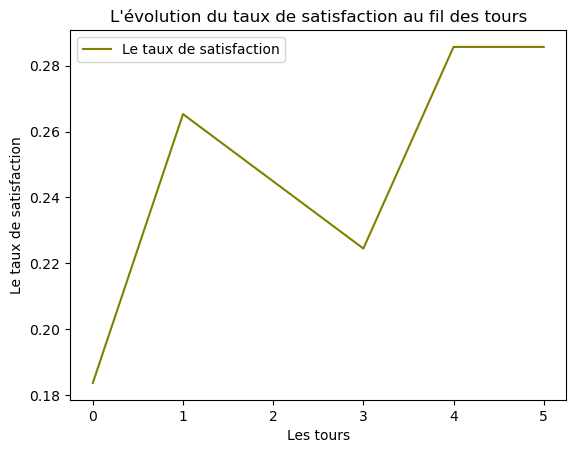

In [330]:
#graph1
def graph_spatial_1(neigh, max_iter, threshold, world):
    worlds = spatial_schelling(neigh, threshold, max_iter, world)
    satisfaction = [happiness_rate_spatial(w, threshold, neigh) for w in worlds]
    return satisfaction

satisfaction_spatial = graph_spatial_1(neigh, max_iter, threshold, spatial_world)

plt.figure()
plt.plot(range(len(satisfaction_spatial)),satisfaction_spatial, label='Le taux de satisfaction', color='olive')
plt.title("L'évolution du taux de satisfaction au fil des tours")
plt.xlabel("Les tours")
plt.ylabel("Le taux de satisfaction")
plt.legend()
plt.draw()

#le graphe montre le taux de satisfaction évolue au fil du temps.

[[0 0 2 1 2 0 2]
 [1 2 2 2 2 2 0]
 [0 1 0 1 2 0 1]
 [2 1 2 0 0 2 0]
 [2 2 0 2 2 2 2]
 [0 0 1 0 0 0 2]
 [0 0 0 1 0 0 0]]
[[1 0 2 0 2 0 2]
 [1 2 2 2 2 2 0]
 [1 1 1 0 2 0 0]
 [2 1 2 0 0 2 0]
 [2 2 0 2 2 2 2]
 [0 0 1 0 0 0 2]
 [0 0 0 1 0 0 0]]
[[1 1 2 0 2 0 2]
 [1 2 2 2 2 2 0]
 [0 1 1 1 2 0 0]
 [2 0 2 1 0 2 0]
 [2 2 1 2 2 2 2]
 [0 0 0 0 0 0 2]
 [0 0 0 0 0 0 0]]
[[0 1 1 2 2 2 2]
 [1 1 1 2 2 2 2]
 [1 0 1 2 2 0 0]
 [2 2 0 0 0 2 2]
 [2 2 0 0 0 2 2]
 [0 0 0 1 0 0 2]
 [0 0 0 0 0 0 0]]
[[0 2 2 2 2 2 2]
 [1 1 2 2 2 2 2]
 [1 1 1 0 2 0 2]
 [1 1 1 0 0 2 2]
 [0 0 0 0 0 2 2]
 [2 0 0 0 0 0 2]
 [0 0 0 0 0 0 0]]
[[2 2 1 2 2 2 2]
 [2 0 0 2 2 2 2]
 [0 1 0 2 2 2 0]
 [0 1 1 0 2 2 2]
 [1 0 0 1 0 2 2]
 [0 0 0 1 0 0 0]
 [0 1 0 0 0 0 0]]
[[1 0 2 2 2 2 2]
 [1 1 0 2 2 2 2]
 [0 1 0 2 2 2 1]
 [0 2 0 2 0 0 0]
 [2 0 1 0 2 2 2]
 [0 0 0 0 2 0 0]
 [0 0 0 0 1 1 0]]
[[2 2 2 1 2 2 2]
 [2 2 2 0 2 2 1]
 [1 0 2 0 2 2 0]
 [2 2 1 0 2 1 1]
 [1 0 0 0 1 0 0]
 [0 2 0 2 0 0 0]
 [0 0 0 0 0 0 0]]
[[0 1 1 2 2 2 2]
 [0 2 2 0 2 1 2]
 [2 1 

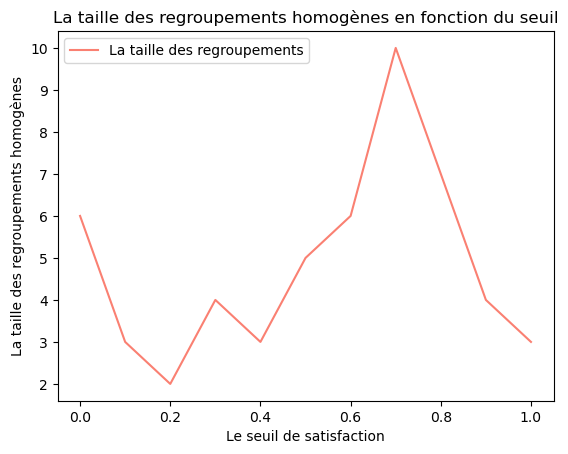

In [331]:
#graph2
threshold_range = np.arange(0, 1.1, 0.1)
def graphe_spatial_2(neigh, max_iter, threshold_range, world):
    nb_regroupements = []
    for threshold in threshold_range:
        worlds = spatial_schelling(neigh,threshold,max_iter,world)
        regroupements = nb_communities_spatial(worlds[-1])
        nb_regroupements.append(regroupements)
    return nb_regroupements

nb_regroupements_spatial = graphe_spatial_2(neigh, max_iter, threshold_range, spatial_world)


plt.figure()
plt.plot(threshold_range,nb_regroupements_spatial , label='La taille des regroupements', color='salmon')
plt.title("La taille des regroupements homogènes en fonction du seuil")
plt.xlabel("Le seuil de satisfaction")
plt.ylabel("La taille des regroupements homogènes")
plt.legend()
plt.draw()

#le graphe1 montre la taille des regroupements homogènes évolue au fil du seuil de satisfaction.

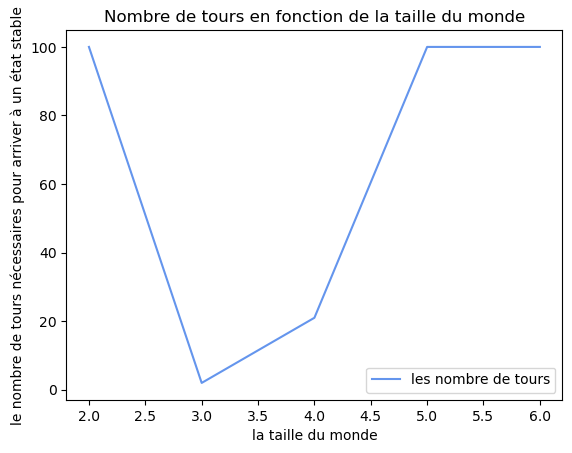

In [332]:
def graphe_spatial_3(neigh, max_iter, threshold):
    worlds = [generate_spatial_world(n, n) for n in range(2, 7)]
    nb_stability = [nb_iter_to_stability(neigh, threshold, max_iter, w) for w in worlds]
    taille = [len(w) for w in worlds]
    return nb_stability,taille

nb_stability_spatial,taille_spatial = graphe_spatial_3(neigh, 100, threshold)

plt.figure()
plt.plot(taille_spatial,nb_stability_spatial,label = 'les nombre de tours',color = 'cornflowerblue')
plt.title("Nombre de tours en fonction de la taille du monde")
plt.xlabel("la taille du monde")
plt.ylabel("le nombre de tours nécessaires pour arriver à un état stable")
plt.legend()
plt.draw()


#le graphe1 montre le nombre de tours nécessaires pour arriver à un état stable évolue au fil de la taille du monde.

**Question 5 (optionnelle) :** Proposer des alternatives au modèle en relâchant certaines hypothèses faites précédemment.  

# 3ème partie : Animation (Interface Graphique avec tkinter)

Développer une animation graphique de l'évolution de votre monde 2D au fil du temps (i.e. des tours),  en utilisant le module tkinter de python. 

In [371]:
import tkinter as Tk

COLORS = {0: "white", 1: "silver", 2: "brown"}

class SchellingAnimation:
    def __init__(self, root, world):
        self.root = root
        self.world = world
        self.history = spatial_schelling(neigh, threshold, 100, world)
        self.step = 0
        self.cell_size = 40 

        self.canvas = Tk.Canvas(root, width=len(world[0]) * 40, height=len(world) * 40)
        self.canvas.pack()
        self.update_canvas()
        self.root.after(120, self.animate)

    def update_canvas(self):
        self.canvas.delete("all")
        for i in range(len(self.world)):
            for j in range(len(self.world[0])):
                color = COLORS[self.history[self.step][i, j]]
                x0, y0 = j * 40, i * 40  
                x1, y1 = x0 + 40, y0 + 40
                self.canvas.create_rectangle(x0, y0, x1, y1, fill=color)

    def animate(self):
        if self.step < len(self.history) - 1:
            self.step += 1
            self.update_canvas()
            self.root.after(120, self.animate)


root = Tk.Tk()
root.title("Schelling Model Animation")
animation = SchellingAnimation(root, generate_spatial_world(15, 15))
root.mainloop()
